In [140]:
# notebook version of the ks script

%matplotlib inline

# Base Python
import os
import platform
from pathlib import Path
# Data handling
import numpy as np
import pandas as pd
import tifffile as tf
import json
# Plotting and animation
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
# For analysis and image processing
from skimage.registration import phase_cross_correlation
from skimage.feature import peak_local_max
from skimage.draw import circle_perimeter
from scipy.optimize import curve_fit
from scipy.ndimage import shift, gaussian_filter, zoom
from scipy.stats import ks_2samp


In [141]:
# Load movie
# field of view at zoom=1 has to be given

fov = 610
fpath = Path("/Users/f/Dropbox/_r66y/data/2p_data/demoMovies/new_movies/AFx_s7_ss5_50lines_L60Mw_00001.tif")
# fpath = ("/Users/f/Dropbox/_r66y/data/2p_data/demoMovies/af10_step_glusnfr4f_10Hz.tif")
analysisWave = None
# path_to_analysisWave = "/Users/f/Dropbox/_r66y/data/2p_data/demoMovies/new_movies/AFx_s7_analysisWave.txt"
x = tf.TiffFile(fpath)
raw_movie = x.asarray()
print(f'loaded: {x}')


loaded: TiffFile 'AFx_s7_s…001.tif'  84.52 MiB  BigTiff  12000 Pages  scanimage|uniform


In [142]:
# get metadata
# the idea is to get info from every tag in metadata

metadata = {}
for key in x.pages[0].tags.keys():
    tag = x.pages[0].tags[key]
    tag_data = x.pages[0].tags[tag.name].value
    # this and software have a lot of data
    if tag.name == 'ImageDescription':
        paired_data = tag_data.split('\n')
        # sometimes they use \r, sometimes \n
        if len(paired_data) == 1:
            paired_data = tag_data.split('\r')
        for i in paired_data:
            try:
                k,v = i.split('=')
                metadata[f'{k.strip()}'] = v.strip()
            except:
                metadata[f'{k.strip()}'] = i
    elif tag.name == 'Software':
        if len(paired_data) == 1:
            paired_data = tag_data.split('\r')
        for i in paired_data:
            try:
                k,v = i.split('=')
                metadata[f'{k.strip()}'] = v.strip()
            except:
                metadata[f'{k.strip()}'] = i
        # Software information changes at page=1, so:
        tag_data1 = x.pages[1].tags[tag.name].value
        paired_data1 = tag_data1.split('\n')
        if len(paired_data1) == 1:
            paired_data1 = tag_data1.split('\r')
        for i in paired_data1:
            try:
                k,v = i.split('=')
                metadata[f'{k.strip()}'] = v.strip()
            except:
                metadata[f'{k.strip()}'] = i
        # the rest is very simple
        metadata[tag.name] = tag_data

for key,value in metadata.items():
    print(f'{key}: {value}')


frameNumbers: 1
acquisitionNumbers: 1
frameNumberAcquisition: 1
frameTimestamps_sec: 0.000000000
acqTriggerTimestamps_sec: -0.000096185
nextFileMarkerTimestamps_sec: -1.000000000
endOfAcquisition: 0
endOfAcquisitionMode: 0
dcOverVoltage: 0
epoch: [2026  7 14 17 31 6.055]
auxTrigger0: []
auxTrigger1: []
auxTrigger2: []
auxTrigger3: []
I2CData: {}
SI.LINE_FORMAT_VERSION: 1
SI.PREMIUM: true
SI.TIFF_FORMAT_VERSION: 4
SI.VERSION_COMMIT: 'd280f35131bb9469227de505be54942d8fb89b0a'
SI.VERSION_MAJOR: 2023
SI.VERSION_MINOR: 1
SI.VERSION_UPDATE: 1
SI.acqState: 'grab'
SI.acqsPerLoop: 1
SI.errorMsg: ''
SI.extTrigEnable: 1
SI.fieldCurvatureRxs: []
SI.fieldCurvatureRys: []
SI.fieldCurvatureTilt: 0
SI.fieldCurvatureTip: 0
SI.fieldCurvatureZs: []
SI.hBeams.enablePowerBox: false
SI.hBeams.errorMsg: ''
SI.hBeams.flybackBlanking: true
SI.hBeams.interlaceDecimation: []
SI.hBeams.interlaceOffset: []
SI.hBeams.lengthConstants: []
SI.hBeams.name: 'SI Beams'
SI.hBeams.powerBoxEndFrame: Inf
SI.hBeams.powerBoxSt

In [143]:
# min metadata for movie
# try ImageDescription, then Software type

frameRate, zoomFactor, scanAngleMultFast, scanAngleMultSlow = None, None, None, None
movie5d, try_software, try_5d = False, False, False
zSlices, zVolumes = None, None

try:
    frameRate = float(metadata["state.acq.frameRate"])
    zoomFactor = float(metadata["state.acq.zoomFactor"])
    scanAngleMultFast = float(metadata["state.acq.scanAngleMultiplierFast"])
    scanAngleMultSlow = float(metadata["state.acq.scanAngleMultiplierSlow"])
except: 
    try_software = True

print(f'\nImage Description:\n\n frameRate={frameRate}\n zoomFactor={zoomFactor}\n scanAngleMultFast={scanAngleMultFast}\n scanAngleMultSlow={scanAngleMultSlow}\n')

if try_software:
    try: 
        frameRate = float(metadata['SI.hRoiManager.scanFrameRate'])
        zoomFactor = float(metadata['SI.hRoiManager.scanZoomFactor'])
        scanAngleMultFast = float(metadata["SI.hRoiManager.scanAngleMultiplierFast"])
        scanAngleMultSlow = float(metadata["SI.hRoiManager.scanAngleMultiplierSlow"])
        try_5d = True
    except:
        print('couldnt find movie metadata')

if try_5d:
    try:
        zSlices = int(metadata.get("SI.hStackManager.actualNumSlices"))
        zFlyback = int(metadata.get("SI.hStackManager.actualStackZStepSize"))
        zLayers = int(metadata.get("SI.hStackManager.numFramesPerVolumeWithFlyback"))
        zVolumes = int(metadata.get("SI.hStackManager.actualNumVolumes"))
        zFrameRate = float(metadata.get("SI.hRoiManager.scanVolumeRate"))
        print(f'\nSoftware:\n\n frameRate={frameRate}\n zoomFactor={zoomFactor}\n scanAngleMultFast={scanAngleMultFast}\n scanAngleMultSlow={scanAngleMultSlow}\n\n zSlices={zSlices}\n zFlyback={zFlyback}\n zLayers={zLayers}\n zVolumes={zVolumes}\n')
        frameRate = zFrameRate
        print(f'actual frameRate = {frameRate}\n')
        movie5d = True
    except:
        print(f'\nSoftware:\n\n frameRate={frameRate}\n zoomFactor={zoomFactor}\n scanAngleMultFast={scanAngleMultFast}\n scanAngleMultSlow={scanAngleMultSlow}\n')




Image Description:

 frameRate=None
 zoomFactor=None
 scanAngleMultFast=None
 scanAngleMultSlow=None


Software:

 frameRate=240.3664651163811
 zoomFactor=10.0
 scanAngleMultFast=1.0
 scanAngleMultSlow=1.0

 zSlices=7
 zFlyback=5
 zLayers=10
 zVolumes=600

actual frameRate = 24.03664651163811



In [144]:
# reshape movie (in case is 4d)

if movie5d:
    print(f'\ntensor shape: {raw_movie.shape}')
    channels, lines, cols = raw_movie.shape[1:]
    raw_movie = raw_movie.reshape(zLayers, zVolumes, channels, lines, cols)
    print(f'reshaped tensor shape: {raw_movie.shape}')
    raw_movie = raw_movie[:zSlices]
    print(f'\ntensor movies shape: {raw_movie.shape}\n')
    


tensor shape: (6000, 2, 50, 50)
reshaped tensor shape: (10, 600, 2, 50, 50)

tensor movies shape: (7, 600, 2, 50, 50)



In [145]:
# deinterleave

if len(raw_movie.shape) == 3:
    channel2 = raw_movie[1::2]
    raw_movie = raw_movie[0::2]
elif len(raw_movie.shape) == 4:
    channel2 = raw_movie[:,1,:,:]
    raw_movie = raw_movie[:,0,:,:]
elif len(raw_movie.shape) == 5:
    channel2 = raw_movie[0,:,1,:,:]
    raw_movie = raw_movie[:,:,0,:,:]

print(f'\nmovie shape: {raw_movie.shape}')
print(f'channel2 shape: {channel2.shape}\n')



movie shape: (7, 600, 50, 50)
channel2 shape: (600, 50, 50)



In [146]:

if movie5d:
    movies = raw_movie.copy()
    print(f'\n{len(movies)} movies of length {movies.shape[1]}: {movies.shape[2]} lines x {movies.shape[3]} cols\n')
else:
    movie = raw_movie.copy()
    print(f'\nmovie shape = {movie.shape}\n')



7 movies of length 600: 50 lines x 50 cols



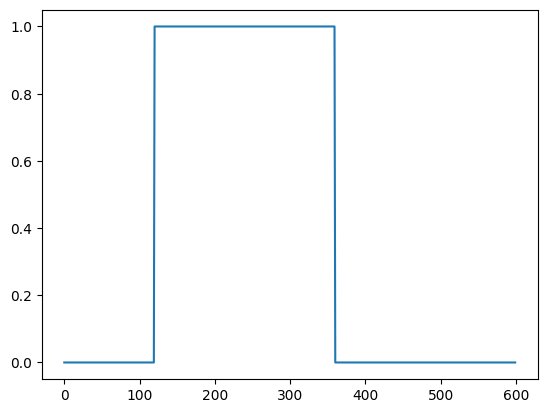

In [147]:
# load/make stimulus 

analysisWave = np.zeros(600)
analysisWave[120:360] = 1

if isinstance(analysisWave, np.ndarray):
    stimulus = analysisWave  
elif os.path.isfile(path_to_analysisWave):
    stimulus = np.loadtxt(path_to_analysisWave)
else:
    stimulus = channel2.mean(axis=(1,2))

plt.plot(stimulus)


In [148]:

# delta: threshold to count as deviation from baseline
delta = 0.01
# get approx mean for comparison
bval = stimulus[1:10].mean()
# replace val at ~ t=0 (first window), to avoid artifacts
stimulus[0] = bval
# if base val = 0, then make everything +1 to avoid null baseline
if bval == 0:
    stimulus += 1
    bval = stimulus[1:10].mean()
baseline = np.where(abs(stimulus-bval) < bval*delta, 0, 1)

if not isinstance(analysisWave, np.ndarray):
    # post_window: time window considered as potentially active (not baseline)
    post_window = 500
    print(f'\npost window = {post_window} ms\n')
    # wx: window after which, even if baseline, signals reflect activity
    # 500 mls in frames (frameRate = framesPerSecond, so half) = 1s/post_window
    wx = int(frameRate * post_window/1000)
    # bis: points where baseline/resting intervals start (skips t=0)
    # if x(t)=rest=0 - x(t-1)=act=1 = -1 => from act to rest
    bis = np.where(baseline-np.roll(baseline,1)==-1)[0]
    # discard post activity windows
    for bi in bis:
        baseline[bi:bi+wx] = 1
        
# remaining points are baseline/rest indices
baseline_idxs = np.where(baseline==0)[0]
activity_idxs = baseline.nonzero()[0]


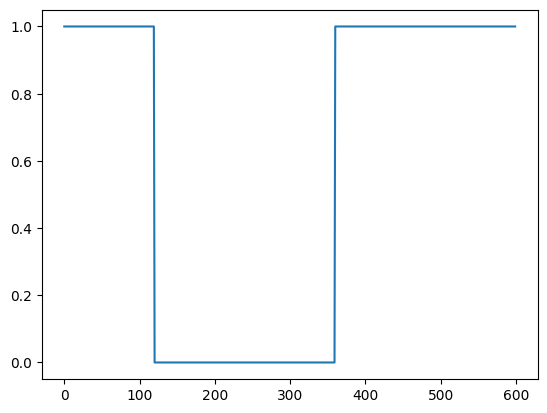

In [149]:
baseline = np.zeros(baseline.shape)
baseline[baseline_idxs] = 1
plt.plot(baseline)

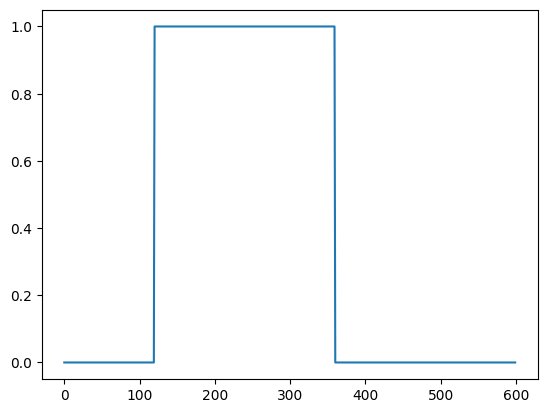

In [150]:
activity = np.zeros(baseline.shape)
activity[activity_idxs] = 1
plt.plot(activity)

In [151]:
# preprocessing: registration

def register(movie, upsample_factor=10):
    nframes = movie.shape[0]
    reference = movie.mean(axis=0)
    movie_reg = np.zeros_like(movie)
    for i in range(nframes):
        shift_est,_,_ = phase_cross_correlation(reference, movie[i], upsample_factor=upsample_factor)
        movie_reg[i] = shift(movie[i], shift_est)
    return movie_reg

if movie5d:
    for i in range(len(movies)):
        movies[i] = register(movies[i].copy())
else:
    movie = register(movie)


In [152]:
# preprocessing: interpolation > square
# making this without a function because the variables may be useful later

print(f'\nfov = {fov}')
print(f'zoomFactor = {zoomFactor}')

def interpolate_square(movie, verbose=True):
    # get real physical sizes of pixels (in microns)
    original_nrows, original_ncols = movie.shape[1:]
    fovx = fov / zoomFactor * scanAngleMultFast
    fovy = fov / zoomFactor * scanAngleMultSlow
    # pixel sizes: px:cols, py:rows
    px = fovx / original_ncols
    py = fovy / original_nrows
    if verbose:
        print(f'original nrows, ncols = {original_nrows}, {original_ncols}')
        print(f'fovx = zoomFactor * scanAngleMultFast = {fovx} µm')
        print(f'fovy = zoomFactor * scanAngleMultSlow = {fovy} µm')
        print(f'pixel size cols = fovx / original ncols = {px} µm')
        print(f'pixel size rows = fovy / original nrows = {py} µm')

    # if pixels are smaller vertically
    if py < px:
        # then we need to make px_eq = py
        # and because: fovx = px_eq * ncols_sq
        ncols_sq = int(round(fovx/py))
        # now we can get px_sq (because npixels has to be int)
        # given: fovx = px_sq * ncols_sq
        px_sq = fovx / ncols_sq
        # zoom operates on movie dims (frames, rows, cols)
        # colZoom is the factor by which we need to increase the number of cols
        colZoom = ncols_sq / original_ncols
        # order 1 = bilinear
        movie = zoom(movie, zoom=(1, 1, colZoom), order=1)
        # py keeps it size
        py_sq = py
    # same, but viceversa
    elif px < py:
        nrows_sq = int(fovy/px)
        py_sq = fovy / nrows_sq
        rowZoom = nrows_sq / original_nrows
        movie = zoom(movie, zoom=(1, rowZoom, 1), order=1)
        px_sq = px
    # else they're already squared
    else:
        px_sq, py_sq = px, py
        
    # new sizes and shapes
    nrows, ncols = movie.shape[1:]
    # pixel size in microns
    pixelSize = (px + py)/2
    if verbose:
        print(f'nrows = {nrows}, ncols = {ncols}')
        print(f'pixelSize = {pixelSize} x {pixelSize} µm\n')
    return movie, pixelSize, nrows, ncols

if movie5d:
    movies[0], pixelSize, nrows, ncols = interpolate_square(movies[0].copy())
    for i in range(1,len(movies)):
        movies[i], pixelSize, nrows, ncols = interpolate_square(movies[i].copy(), verbose=False)
else:
    movie, pixelSize, nrows, ncols = interpolate_square(movie)



fov = 610
zoomFactor = 10.0
original nrows, ncols = 50, 50
fovx = zoomFactor * scanAngleMultFast = 61.0 µm
fovy = zoomFactor * scanAngleMultSlow = 61.0 µm
pixel size cols = fovx / original ncols = 1.22 µm
pixel size rows = fovy / original nrows = 1.22 µm
nrows = 50, ncols = 50
pixelSize = 1.22 x 1.22 µm



In [153]:
def bleach_correction(movie, framerate, rescale=True):
    # reference
    nframes = movie.shape[0]
    frame_mean = movie.mean(axis=(1,2))
    def exp_decay(t,A,tau,C):
        return A*np.exp(-t/tau)+C
    # t = np.arange(self.nframes)/frameRate
    t = np.arange(movie.shape[0])/frameRate
    # initial guess for params
    p0 = [frame_mean[0] - frame_mean[-1], nframes/frameRate/2, frame_mean[-1]]
    # fits a curve to the bleaching using frame_mean as reference
    # params = [A_fit, tau_fit, C_fit]
    params,_ = curve_fit(exp_decay,t,frame_mean,p0=p0,maxfev=10000)
    # evaluate at every t
    fit_curve = exp_decay(t,*params)
    if not rescale:
        # divide each frame by fit curve value - 1e-8 is simply to avoid zero div
        movie = movie / np.maximum(fit_curve[:,None,None],1e-8)
    else:
        # same but rescaled (otherwise you risk normalizing)
        movie = movie * (fit_curve[0] / np.maximum(fit_curve[:,None,None],1e-8))
    return movie

if movie5d:
    for i in range(len(movies)):
        movies[i] = bleach_correction(movies[i].copy(), frameRate)
else:
    movie = bleach_correction(movie, frameRate)


In [154]:
# define ROI size
# how many pixels per synapse + round it up, because most likely
# synapses won't fit exactly the pixel grid -> |(| |)|

# aprox. size in microns (µm x µm)
roiSize = 2
# min number of pixels between ROI peak centres (for 2D gaussians)
min_distance = 3

# (cannot be < 1 pixel)
roi_radius = np.ceil(roiSize/pixelSize)/2
# if min distance between peaks < roi radius (radius of gaussians)
# then the demixing won't make sense
if min_distance < roi_radius:
    min_distance = int(roi_radius) + 1

print(f'\nROI size = {roiSize} x {roiSize} µm')
print(f'pixel size = {pixelSize} x {pixelSize} µm')
print(f'min distance = {min_distance} pixels = {min_distance * pixelSize} µm')
print(f'ROI radius = {int(roi_radius)} pixels = {roi_radius * pixelSize} µm\n')



ROI size = 2 x 2 µm
pixel size = 1.22 x 1.22 µm
min distance = 3 pixels = 3.66 µm
ROI radius = 1 pixels = 1.22 µm



movie 0:

candidate peaks found = 36



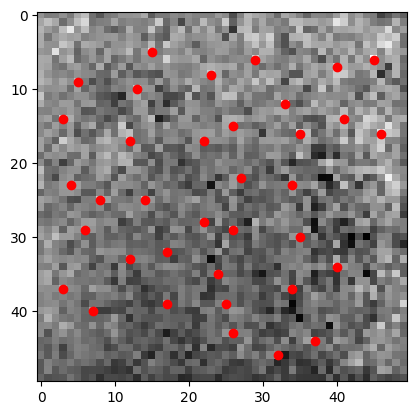

movie 1:

candidate peaks found = 34



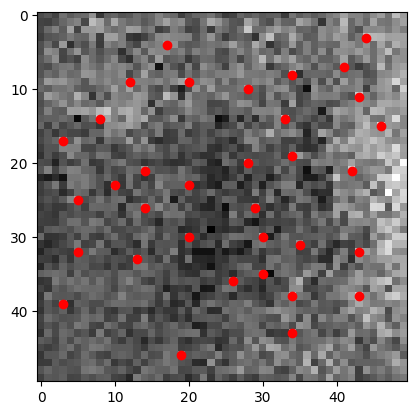

movie 2:

candidate peaks found = 26



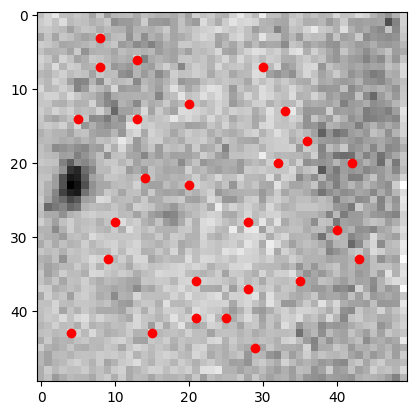

movie 3:

candidate peaks found = 30



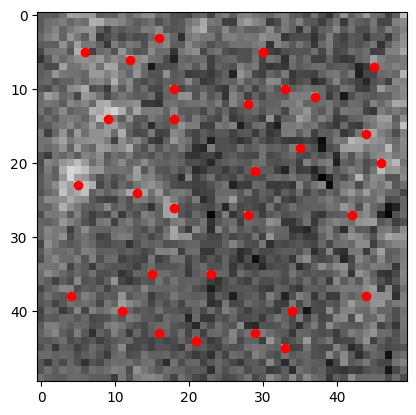

movie 4:

candidate peaks found = 38



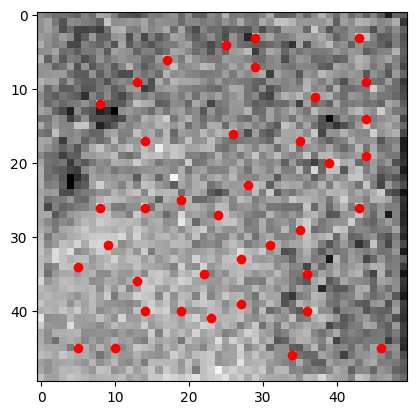

movie 5:

candidate peaks found = 22



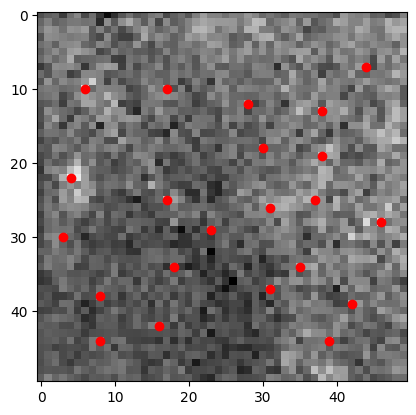

movie 6:

candidate peaks found = 39



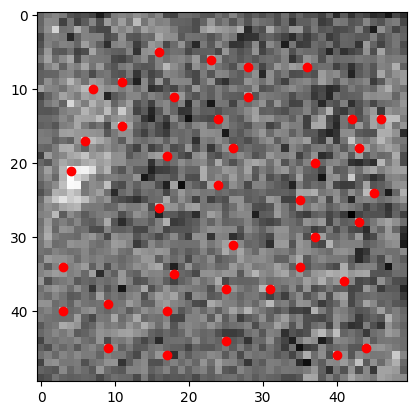

In [155]:
# find candidates

def mk_delta_fmap(movie, baseline_idxs, activity_idxs, sigma_smooth = 0, threshold_percentile = 70, edge_margin = 3):
    # split in baseline & activity
    baseline_mean = movie[baseline_idxs].mean(axis=0)
    activity_mean = movie[activity_idxs].mean(axis=0)
    deltaf_map = gaussian_filter(activity_mean - baseline_mean, sigma=sigma_smooth)
    # minimum intensity for pixels
    threshold_abs = np.percentile(deltaf_map, threshold_percentile)
    # local max in: 2 * min distance + 1
    deltaf_peaks = peak_local_max(deltaf_map,
                    min_distance=min_distance,
                    threshold_abs=threshold_abs,
                    exclude_border=edge_margin)
    print(f'\ncandidate peaks found = {len(deltaf_peaks)}\n')
    # plot for reference
    plt.imshow(deltaf_map, cmap='gray')
    plt.scatter(*deltaf_peaks[:, ::-1].T, color='red')
    plt.show()
    return deltaf_map, deltaf_peaks

if movie5d:
    movies_deltaf_peaks, movies_deltaf_maps = [], []
    for i in range(len(movies)):
        print(f'movie {i}:')
        deltaf_map, deltaf_peaks = mk_delta_fmap(movies[i], baseline_idxs, activity_idxs)
        movies_deltaf_peaks.append(deltaf_peaks)
        movies_deltaf_maps.append(deltaf_map)
else:
    deltaf_map, deltaf_peaks = mk_delta_fmap(movie, baseline_idxs, activity_idxs)

movie 0:

synapses found = 4



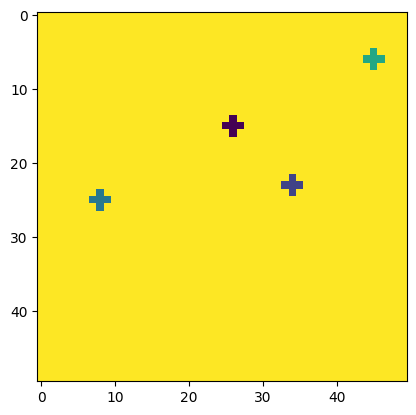

movie 1:

synapses found = 3



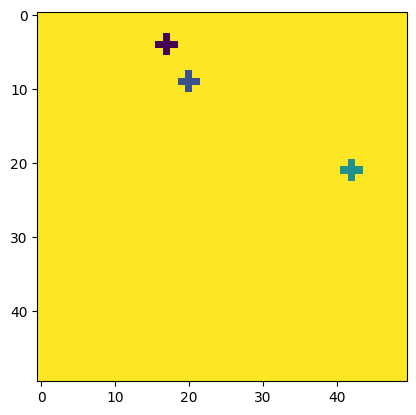

movie 2:

no significant points were found

movie 3:

synapses found = 2



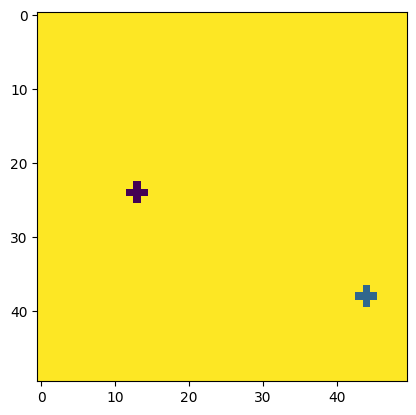

movie 4:

synapses found = 2



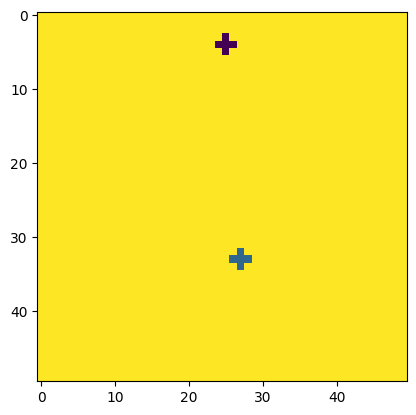

movie 5:

synapses found = 2



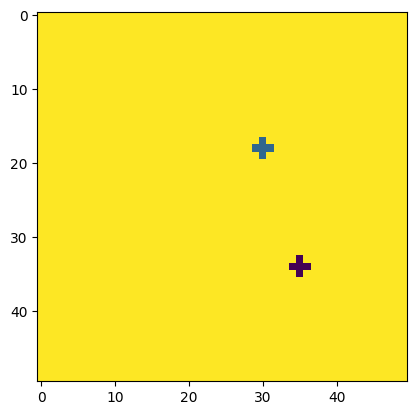

movie 6:

no significant points were found



In [156]:
# evaluate peaks

def ks_distance(movie, baseline_idxs, activity_idxs, deltaf_peaks, roi_radius, alpha=0.05):
    nrows, ncols = movie.shape[-2:]
    roi_radius = int(roi_radius)
    ks_peaks = []
    # meshgrid for rows and cols
    yy, xx = np.indices((nrows, ncols))
    # make ROIs from pixels
    for y0,x0 in deltaf_peaks:
        # x^2 + y^2 = r^2
        mask = ((yy-y0)**2 + (xx-x0)**2) <= roi_radius**2
        # vals: pixel vals in circular region around pixel across movie
        # [:,mask] doesn't preserve shape: returns 1d arr for each frame
        baseline_vals = movie[baseline_idxs][:,mask].mean(axis=1)
        activity_vals = movie[activity_idxs][:,mask].mean(axis=1)
        # ΔF/F = (f1-f0)/f0
        f0 = baseline_vals.mean()
        f1 = activity_vals.mean()
        dff = (f1-f0)/f0 if f0 > 0 else np.nan
        # ks
        dist,pval = ks_2samp(baseline_vals, activity_vals)
        ks_peaks.append([y0,x0,dff,dist,pval])
    # ks peaks = [y0, x0, dff, ks dist, ks pval]
    # sort by p-vals
    ks_peaks = np.array(sorted(ks_peaks, key=lambda x:x[-1]))
    # < alpha
    pvals = ks_peaks[:,-1]
    significant = np.where(pvals < alpha)[0]
    if not np.any(significant):
        print('\nno significant points were found\n')
        synapses = np.array([])
    else:
        # remove non significant
        ks_peaks = ks_peaks[significant]
        # sort by ΔF/F and keep coords only (row, col, df/f, ks-d, ks-p)
        ks_peaks = np.array(sorted(ks_peaks, key=lambda x:x[4], reverse=False))
        synapses = ks_peaks[:,:2].astype(int)
        print(f'\nsynapses found = {len(synapses)}\n')

    # masked 2d arrays for synapses
    # pixel mask: focal point for 2d gaussians
    # roi mask: area/pixels to be the ROI/synapse
    synapses_mask_pixels = np.full(movie.shape[1:], 1, dtype=np.int16)
    synapses_mask_rois = np.full(movie.shape[1:], 1, dtype=np.int16)
    if len(synapses) > 0:
        for ei, (row, col) in enumerate(synapses):
            val = -(ei + 1)
            synapses_mask_pixels[row,col] = val
            disk = ((yy-row)**2 + (xx-col)**2) <= roi_radius**2
            free = disk & (synapses_mask_rois == 1)
            synapses_mask_rois[free] = val
        # display roi mask to get a quick idea
        plt.imshow(synapses_mask_rois)
        plt.show()
    else:
        synapses_mask_pixels, synapses_mask_rois = [], []
        
    return ks_peaks, synapses, synapses_mask_pixels, synapses_mask_rois

if movie5d:
    movies_ks_peaks, movies_synapses, movies_pixel_masks, movies_roi_masks = [], [], [], []
    for i in range(len(movies)):
        print(f'movie {i}:')
        ks_peaks, synapses, pixel_mask, roi_mask = ks_distance(movies[i], baseline_idxs, activity_idxs, movies_deltaf_peaks[i], roi_radius)
        movies_ks_peaks.append(ks_peaks)
        movies_synapses.append(synapses)
        movies_pixel_masks.append(pixel_mask)
        movies_roi_masks.append(roi_mask)
else:
    ks_peaks, synapses, pixel_mask, roi_mask = ks_distance(movie, baseline_idxs, activity_idxs, deltaf_peaks, roi_radius)


In [157]:
# demixing of statistically significant peaks

def ridge_demixing(movie, synapses, sigma_fit=1, lambda_reg=0.05, edge_margin=3):
    nframes, nrows, ncols = movie.shape
    if len(synapses) == 0:
        return []
    # unzip, same as zip(*synapses)
    ys, xs = np.array(synapses).T
    # discard margins
    ymin = max(0, ys.min()-edge_margin)
    ymax = min(ys.max()+edge_margin, nrows)
    xmin = max(0, xs.min()-edge_margin)
    xmax = min(xs.max()+edge_margin, ncols)
    sy = ymax - ymin
    sx = xmax - xmin
    # for the gaussians
    gs_list = []
    yy, xx = np.indices((sy,sx))
    for y0,x0 in synapses:
        # creates a 2d gaussian centered around pixel
        gi = np.exp(-((xx-(x0-xmin))**2 + (yy-(y0-ymin))**2)/(2*sigma_fit**2))
        gs_list.append(gi.ravel())
    # array of flattended gaussians
    gs = np.column_stack(gs_list)
    # cov matrix - here @ is the same as .matmul()
    # each element (i,j) is the dot product between:
    # the gaussian of synape i and the gaussian of synapse j
    # so the diagonal: dot product with itself => size
    # => the off-diagonal values represent overlap among synapses
    gs_cov = gs.T @ gs
    # lambda reg adds a small value to the diagonal (* np.eye)
    # so too small makes the solution unstable
    # too large it looses signals (makes weights almost 0)
    # here is basically hardcoded
    gs_demix = np.linalg.solve(gs_cov + lambda_reg * np.eye(gs_cov.shape[0]), gs.T)
    # get amplitudes
    gs_amps = np.zeros((synapses.shape[0],nframes))
    # for nf in range(self.nframes):
    #     frame = self.movie[nf,ymin:ymax,xmin:xmax].flatten()
    #     # example: 23 x (~128x128).flat @ (~128x128).flat x 1 => 23 x 1
    #     self.gs_amps[:,nf] = gs_demix @ frame
    # this vectorized version is faster, but it may be good to double check 
    frames = movie[:, ymin:ymax, xmin:xmax].reshape(nframes, -1).T
    gs_amps = gs_demix @ frames
    # plt.imshow(gs_amps)
    # plt.show()
    return gs_amps

if movie5d:
    movies_gs_amps = []
    for i in range(len(movies)):
        gs_amps = ridge_demixing(movies[i], movies_synapses[i])
        movies_gs_amps.append(gs_amps)
else:
    gs_amps = ridge_demixing(movie, synapses)


In [158]:

def compute_dff_traces(gs_amps, activity_idxs):
    if len(gs_amps) == 0:
        return []
    # skips initial frames, to avoid artifacts
    baseline_idxs_dff = np.arange(20,activity_idxs[0])
    # baseline_idxs_dff = np.arange(activity_idxs[0])
    # get traces
    dff_traces = []
    for i,amp in enumerate(gs_amps):
        f0 = np.median(amp[baseline_idxs_dff])
        dff_traces.append((amp-f0)/f0)
    dff_traces = np.array(dff_traces)
    return dff_traces

if movie5d:
    movies_dff_traces = []
    for i in range(len(movies_gs_amps)):
        dff_traces = compute_dff_traces(movies_gs_amps[i], activity_idxs)
        movies_dff_traces.append(dff_traces)
else:
    dff_traces = compute_dff_traces(gs_amps, activity_idxs)


movie 0:


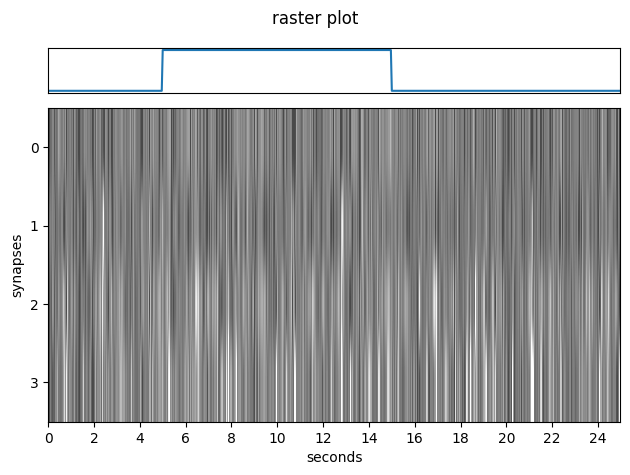

movie 1:


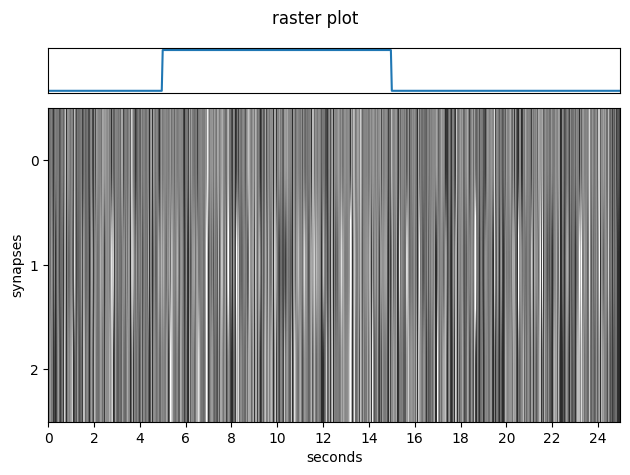

movie 2:

empty trace

movie 3:


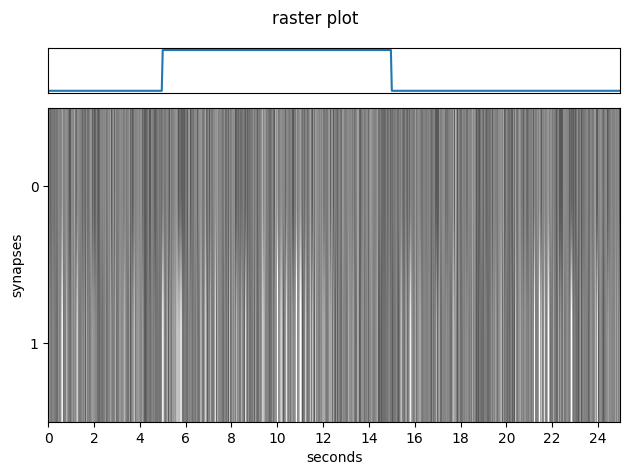

movie 4:


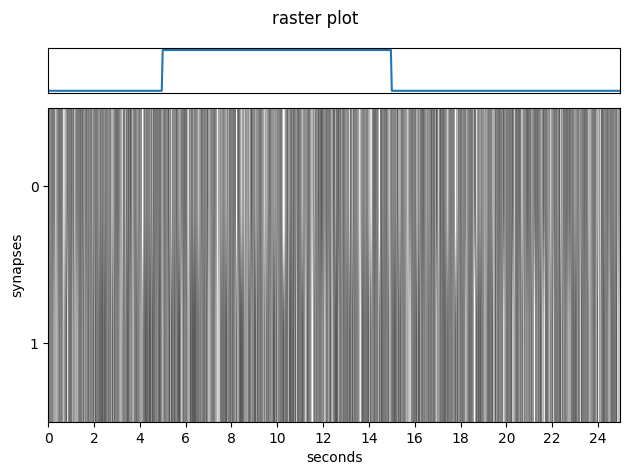

movie 5:


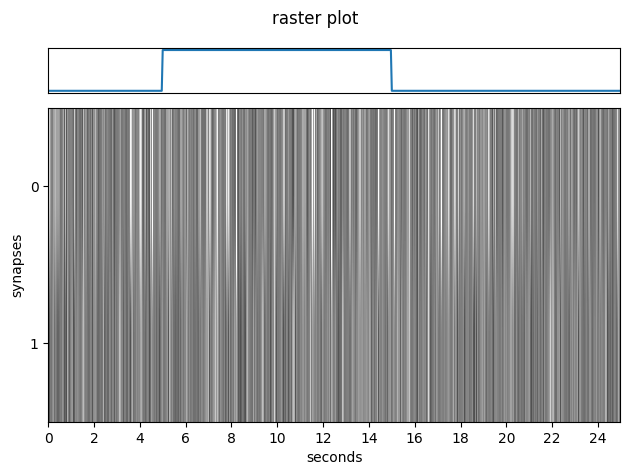

movie 6:

empty trace



In [159]:
def plot_raster(dff_traces, stimulus, frameRate, title=''):
    if len(dff_traces) == 0:
        print('\nempty trace\n')
        return
    duration = stimulus.shape[0]/frameRate
    f, (a0,a1) = plt.subplots(2,1, gridspec_kw={'height_ratios': [1,7]})
    # for traces in seconds
    t = np.linspace(0,dff_traces[0].size/frameRate,dff_traces[0].size)
    a0.plot(t,stimulus)
    a0.set_xlim(xmin=0, xmax=duration)
    a0.set_xticks([])
    a0.set_yticks([])
    # raster
    # for imshow we can't change the data
    vmax=np.percentile(np.abs(dff_traces),99)
    a1.imshow(dff_traces, aspect='auto', cmap='gray',
              vmin=-vmax,vmax=vmax,
              extent=[0,duration,0,dff_traces.shape[0]])
    # x ticks (time)
    a1.set_xticks(np.arange(0,duration+1,int(duration/10)))
    # y ticks need to be inverted (from best to worst)
    n_synapses = len(dff_traces)
    ticks = np.arange(n_synapses) + 0.5        
    a1.set_yticks(ticks)
    a1.set_yticklabels(np.arange(n_synapses -1, -1, -1))
    # labels
    a1.set_ylabel("synapses")
    a1.set_xlabel("seconds")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

if movie5d:
    for i in range(len(movies_dff_traces)):
        print(f'movie {i}:')
        plot_raster(movies_dff_traces[i], stimulus, frameRate, title='raster plot')
else:
    plot_raster(dff_traces, stimulus, frameRate, title='raster plot')


movie 0:


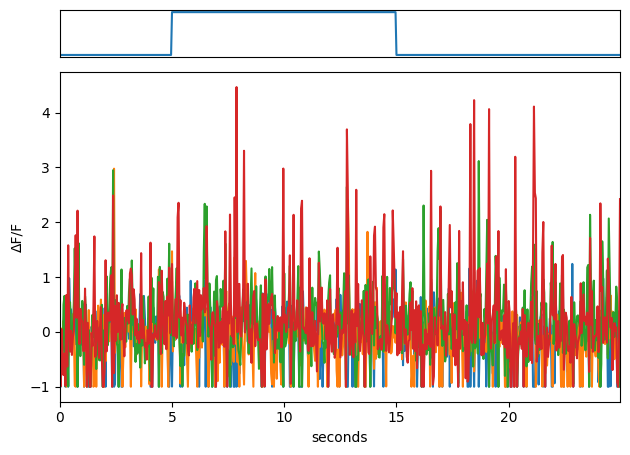

movie 1:


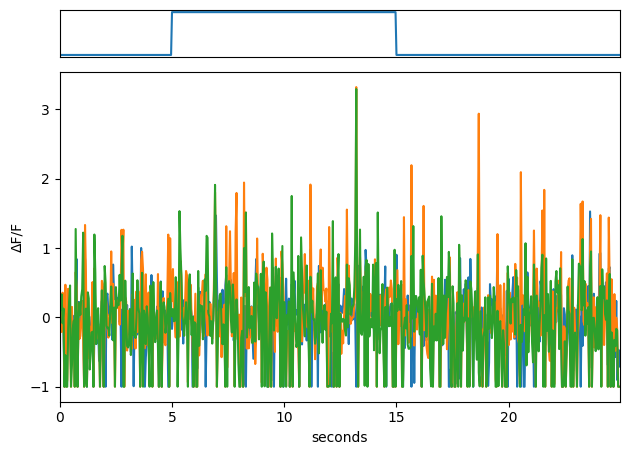

movie 2:

empty trace

movie 3:


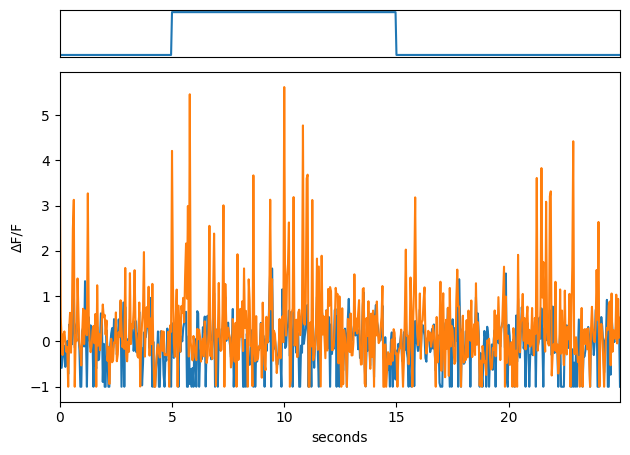

movie 4:


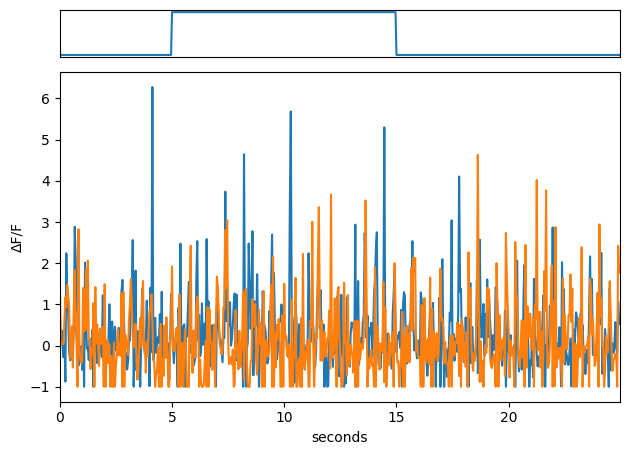

movie 5:


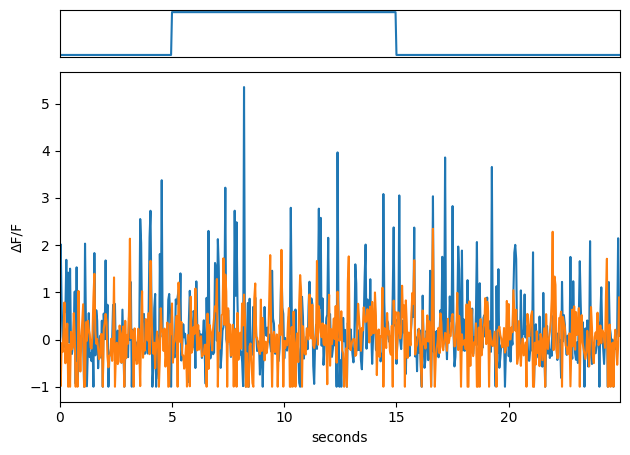

movie 6:

empty trace



In [160]:
def plot_traces(dff_traces, stimulus, frameRate, n=5, title=''):
    if len(dff_traces) == 0:
        print('\nempty trace\n')
        return
    duration = stimulus.shape[0]/frameRate
    f, (a0,a1) = plt.subplots(2,1, gridspec_kw={'height_ratios': [1,7]})
    # for traces in seconds
    t = np.linspace(0,dff_traces[0].size/frameRate,dff_traces[0].size)
    a0.plot(t,stimulus)
    a0.set_xlim(xmin=0, xmax=duration)
    a0.set_xticks([])
    a0.set_yticks([])
    for ni in range(min(n,len(dff_traces))):
        a1.plot(t,dff_traces[ni])
    a1.set_xlim(xmin=0, xmax=duration)
    a1.set_ylabel("ΔF/F")
    a1.set_xlabel("seconds")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

if movie5d:
    for i in range(len(movies_dff_traces)):
        print(f'movie {i}:')
        plot_traces(movies_dff_traces[i], stimulus, frameRate)
else:
    plot_traces(dff_traces, stimulus, frameRate)


movie 0:


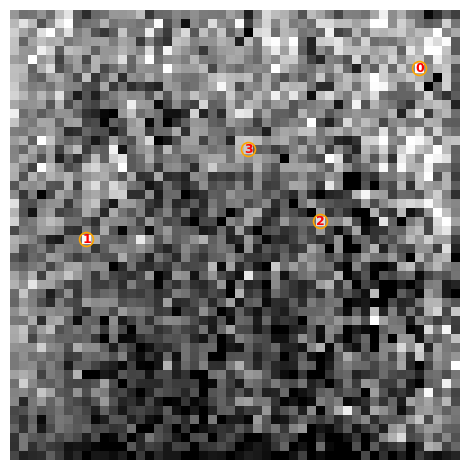

movie 1:


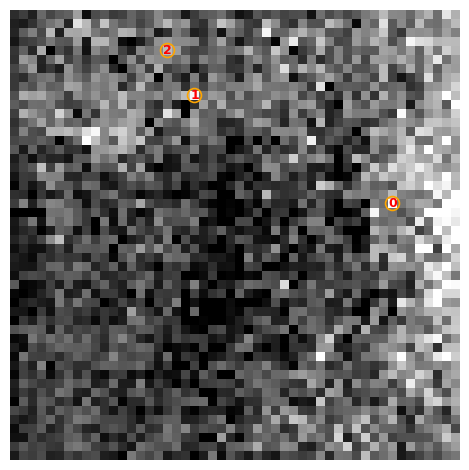

movie 2:

empty trace

movie 3:


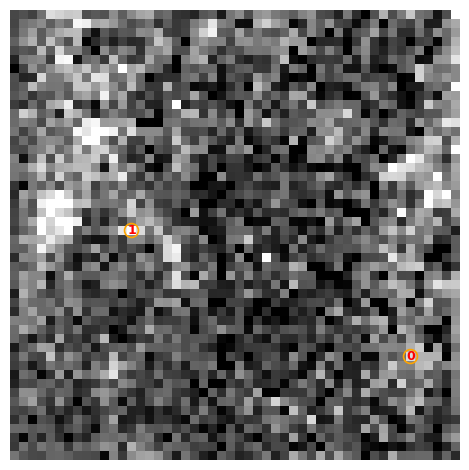

movie 4:


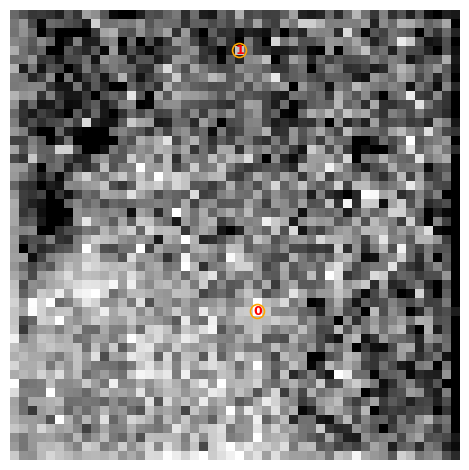

movie 5:


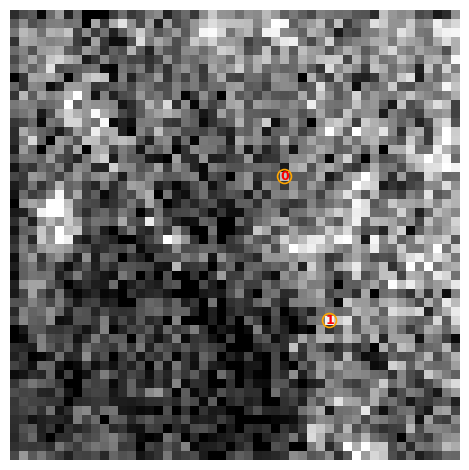

movie 6:

empty trace



In [161]:
def plot_synapses(deltaf_map, synapses, roi_radius, th_vmin=5, th_vmax=99):
    if len(synapses) == 0:
        print('\nempty trace\n')
        return
    vmin = np.percentile(deltaf_map, th_vmin)
    vmax = np.percentile(deltaf_map, th_vmax)
    plt.imshow(deltaf_map, cmap='gray', vmin=vmin, vmax=vmax)
    plt.axis('off')
    # plot synapses
    for ei,(sy,sx) in enumerate(synapses):
        # s: typographic points ** 2 & typographic points = 1/72 inches.
        # tp = 1*2.54/72 = 0.35277 
        plt.scatter(sx,sy,s=roi_radius*100,facecolors='none',edgecolor='orange',linewidths=1.2)
        # write n in list
        plt.text(sx,sy,str(ei),
            color='red',fontsize=9,
            ha='center',va='center',fontweight='bold')
    plt.tight_layout()
    plt.show()

if movie5d:
    for i in range(len(movies)):
        print(f'movie {i}:')
        plot_synapses(movies_deltaf_maps[i], movies_synapses[i], roi_radius)   
else:
    plot_synapses(deltaf_map, synapses, roi_radius)

In [165]:
# save

savedir = "/Users/f/Desktop/ksOutput"
if not os.path.isdir(savedir):
    os.mkdir(savedir)
if not os.path.isdir(savedir):
    savedir = os.getcwd()
# fname = fpath.split(os.path.sep)[-1].split('.')[0]
fname = fpath.stem
savepath = os.path.join(savedir,fname)

if movie5d:
    for i in range(len(movies)):
        if len(movies_synapses[i]) > 0:
            dfx = pd.DataFrame(movies_ks_peaks[i], columns=["row","col","dF/F","ks-d","ks-p"])
            dfx.to_csv(f'{savepath}_synapses_data{i}.csv')
            tf.imwrite(f'{savepath}_pixelmask{i}.tif', movies_pixel_masks[i])
            tf.imwrite(f'{savepath}_roimask{i}.tif', movies_roi_masks[i])
            tf.imwrite(f'{savepath}_dff_traces{i}.tif', movies_dff_traces[i])
else:
    dfx = pd.DataFrame(ks_peaks, columns=["row","col","dF/F","ks-d","ks-p"])
    dfx.to_csv(f'{savepath}_synapses_data.csv')
    tf.imwrite(f'{savepath}_pixelmask.tif', synapses_mask_pixels)
    tf.imwrite(f'{savepath}_roimask.tif', synapses_mask_rois)
    tf.imwrite(f'{savepath}_dff_traces.tif', dff_traces)

# metadata
mpath = os.path.join(savedir,f'{fname}_metadata.txt')
with open(mpath, "w") as f:
    for k,v in metadata.items():
        # remove commas to avoid data being truncated when read in igor
        v_str = str(v).replace(',',' ')
        f.write(f'{k}={v_str}\n')
print(f'saved to: {savedir}')


saved to: /Users/f/Desktop/ksOutput
